# Matplotlib Tutorial — Thesis-Focused
**Preparation Phase · Bachelor's Thesis: Benchmarking Tabular Data Augmentation Techniques for Deep Clustering**

Background: pandas ✓ · numpy (basic) · matplotlib ← you are here

This notebook covers the six matplotlib skills you need for your thesis — nothing more.

| § | Plot type | Where you will use it |
|---|-----------|----------------------|
| 1 | Figure / Axes model | Foundation for every plot |
| 2 | `scatter` | Visualising 2D cluster embeddings |
| 3 | `plot` (line) | Training loss curves |
| 4 | `hist` | Feature distributions (data exploration) |
| 5 | `barh` | NMI / ARI comparison across augmentations |
| 6 | `subplots` | Multi-panel results figures |
| 7 | `savefig` | PDF export for LaTeX |
| ★ | **Capstone** | Given results dict → `capstone_results.pdf` |

**Structure of each section:** explanation → worked example → mini-example you can run → your exercise → solution.

---
## Before You Run Anything: Understanding the Shared Data

The first code cell creates all the data used throughout the notebook.
Read this section first so the variables make sense before you see them in a plot.

---

### What are "embeddings" and why do we plot them?

In your thesis, a neural network (MLP) processes each row of your tabular dataset
and compresses it into a short vector of numbers — for example, 64 numbers.
This short vector is called an **embedding**: a learned fingerprint of that data point.

If training went well, data points from the same cluster should have similar fingerprints
(their embeddings are close together in space), and data points from different clusters
should have different fingerprints (their embeddings are far apart).

**The problem:** 64 numbers live in 64-dimensional space. We cannot plot that.

**The solution — PCA:** PCA (Principal Component Analysis) is a method that takes
your cloud of high-dimensional points and finds the 2 directions in which the data
varies the most. It then projects every point onto those 2 directions, giving 2 numbers
per point — something you can plot on an x–y plane.

> **Analogy:** Imagine a sculpture hanging in a room. You shine a light on it and look
> at the shadow on the wall. PCA finds the angle of the light that produces the most
> informative shadow — the one that best shows the 3D structure in 2D.

**Why plot embeddings?** It is a visual sanity check. If the network learned to
separate clusters, you should see distinct blobs of colour. If everything is one
random cloud, training failed.

**In this notebook:** we skip the actual PCA (that is a scikit-learn topic).
Instead, we *simulate* what PCA output looks like — 240 points in 3 coloured blobs.
The plotting code you learn here is exactly what you will use for real embeddings.

---

### Variable guide

| Variable | Shape | What it represents |
|----------|-------|-------------------|
| `X` | (240, 2) | 240 simulated 2D embeddings — 80 points per cluster |
| `cluster_labels` | (240,) | True cluster label (0, 1, or 2) for each point in `X` |
| `epochs` | (50,) | Epoch numbers 1 to 50 |
| `loss_tr` | (50,) | Simulated training loss at each epoch |
| `loss_val` | (50,) | Simulated validation loss at each epoch |
| `feat_age` | (400,) | Simulated age feature — bell-curve shaped |
| `feat_income` | (400,) | Simulated income feature — skewed right |
| `nmi` | dict | NMI score per augmentation technique |
| `ari` | dict | ARI score per augmentation technique |

---

### A note on randomness — `np.random.default_rng(42)`

Many arrays below are randomly generated (they simulate noisy real data).
To ensure you get the **same** random numbers every time you run the notebook,
we create a random number generator (`rng`) and lock it to a fixed starting point — 42.
This is called a **random seed**. The number 42 is arbitrary; any integer works.

In [81]:
import numpy as np           # numerical arrays and math operations
import matplotlib.pyplot as plt  # the plotting library

# Fixed-seed random number generator — guarantees reproducibility.
rng = np.random.default_rng(42)


# ── §2 DATA: Simulated 2D embeddings, 3 clusters ───────────────────────────

n = 80   # number of points per cluster  (3 clusters × 80 = 240 total)

# (x, y) centre of each cluster in 2D space
centers = [(1.0, 1.0), (4.0, 1.0), (2.5, 4.0)]

# np.repeat([0, 1, 2], 80) produces:
#   [0, 0, ...(80 times)..., 1, 1, ...(80 times)..., 2, 2, ...(80 times)...]
# We need one label per data point (240 labels total).
cluster_labels = np.repeat([0, 1, 2], n)
print(cluster_labels)
# For each centre c, generate n=80 random 2D points scattered around it.
#
#   rng.multivariate_normal(centre, spread_matrix, n_points)
#     centre        = (x, y) position of the cluster
#     spread_matrix = 0.4 * np.eye(2)
#                     np.eye(2) is [[1, 0], [0, 1]] (identity matrix)
#                     0.4 * np.eye(2) = [[0.4, 0], [0, 0.4]]
#                     → points scatter ≈0.4 units in both x and y
#                     → the zeros mean x and y vary independently
#     n_points      = 80
#
# np.vstack stacks the three (80, 2) arrays into one (240, 2) array
# — like stacking three spreadsheets of 80 rows into one of 240 rows.
X = np.vstack([
    rng.multivariate_normal(c, 0.4 * np.eye(2), n) for c in centers
])
# X.shape = (240, 2): 240 rows (points), 2 columns (x-coord, y-coord)


# ── §3 DATA: Training / validation loss over 50 epochs ────────────────────

# np.arange(1, 51) → [1, 2, 3, ..., 50]  (one integer per epoch)
epochs = np.arange(1, 51)

# np.exp(-0.08 * epochs): exponential decay curve — starts near 2.0, falls toward 0.
# + 0.12: a floor the loss approaches but never quite reaches.
# + 0.03 * rng.standard_normal(50): tiny random noise.
#   rng.standard_normal(50) gives 50 values from a bell curve (avg ≈ 0).
#   Multiplied by 0.03, the noise is small but makes the curve look realistic.
loss_tr  = 2.0 * np.exp(-0.08 * epochs) + 0.12 + 0.03 * rng.standard_normal(50)
loss_val = 2.0 * np.exp(-0.07 * epochs) + 0.18 + 0.04 * rng.standard_normal(50)
# Validation loss falls slightly slower (-0.07 vs -0.08) and has more noise (0.04 vs 0.03).


# ── §4 DATA: Simulated tabular features ───────────────────────────────────

# rng.normal(mean, std, count): 400 values from a bell curve centred at 35
# with a spread of ±10. Simulates an 'age' column.
feat_age = rng.normal(35, 10, 400)

# rng.exponential(scale, count): 400 values from a right-skewed distribution.
# Most values are small; a few are very large. Simulates an 'income' column.
feat_income = rng.exponential(40, 400)


# ── §5 DATA: Benchmark results ─────────────────────────────────────────────

# NMI and ARI both range from 0 (random) to 1 (perfect).
# You know these from your Data Mining course.
nmi = {'Baseline': 0.41, 'Gauss. Noise': 0.54,
       'Feat. Masking': 0.61, 'Feat. Swap': 0.58, 'Mixup': 0.49}
ari = {'Baseline': 0.38, 'Gauss. Noise': 0.50,
       'Feat. Masking': 0.57, 'Feat. Swap': 0.53, 'Mixup': 0.45}


print('Setup complete. Shapes:')
print(f'  X: {X.shape}   cluster_labels: {cluster_labels.shape}')
print(f'  epochs: {epochs.shape}   loss_tr: {loss_tr.shape}')
print(f'  feat_age: {feat_age.shape}   feat_income: {feat_income.shape}')

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Setup complete. Shapes:
  X: (240, 2)   cluster_labels: (240,)
  epochs: (50,)   loss_tr: (50,)
  feat_age: (400,)   feat_income: (400,)


---
## §1 The Figure / Axes Model

Before drawing anything, you need to understand the two objects that matplotlib uses for every plot.

- **`Figure`** — the whole canvas (like a blank sheet of paper on a table).
- **`Axes`** — one plot panel inside the canvas (like a framed window stuck onto the paper). This is the object you actually draw on.

You create both at the same time with:

```python
fig, ax = plt.subplots()           # 1 panel
fig, axes = plt.subplots(1, 3)     # 3 panels side by side  → axes is a list of 3
fig, axes = plt.subplots(2, 2)     # 2×2 grid of panels     → axes is a 2D array
```

**Always use `ax.plot()`, never `plt.plot()` directly.**
The reason: when you have multiple panels (§6), `plt.plot()` does not know which panel
to draw on. `ax.plot()` is explicit — you choose the panel.

**`figsize=(width, height)`** sets the canvas size in inches.
A typical thesis figure is 5–7 inches wide and 3–4 inches tall.

**`plt.tight_layout()`** automatically adjusts spacing so axis labels do not overlap.
Call it just before `plt.show()`.

**`plt.show()`** renders the figure and displays it in the notebook.

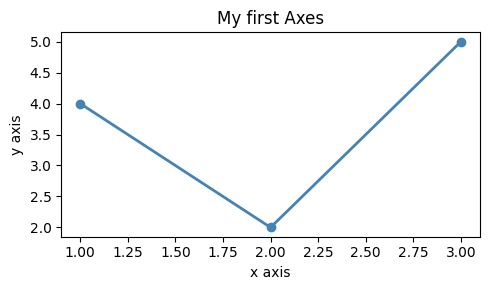

In [82]:
# ── §1 Worked example ───────────────────────────────────────────────────────

# plt.subplots() creates a Figure and one Axes simultaneously.
# figsize=(5, 3): canvas is 5 inches wide, 3 inches tall.
# Returns two objects: fig (the whole canvas) and ax (the one plot panel).
fig, ax = plt.subplots(figsize=(5, 3))

# ax.plot(x_values, y_values, ...) draws a line through the given points.
# color='steelblue' — a named colour (matplotlib knows hundreds of colour names)
# marker='o'        — draw a filled circle at each data point
# lw=2              — line width: 2 points thick (default is 1.5)
ax.plot([1, 2, 3], [4, 2, 5], color='steelblue', marker='o', lw=2)

ax.set_title('My first Axes')   # text above the plot
ax.set_xlabel('x axis')         # label below the x-axis
ax.set_ylabel('y axis')         # label to the left of the y-axis

plt.tight_layout()   # prevent label clipping
plt.show()           # display

### Exercise 1

Create a 1×2 figure (two side-by-side panels). Plot `y = x²` on the left and `y = √x` on the right.
Set the title of each panel to `'Left'` and `'Right'`.

The mini-example below shows the skeleton — run it first, then fill in the template.

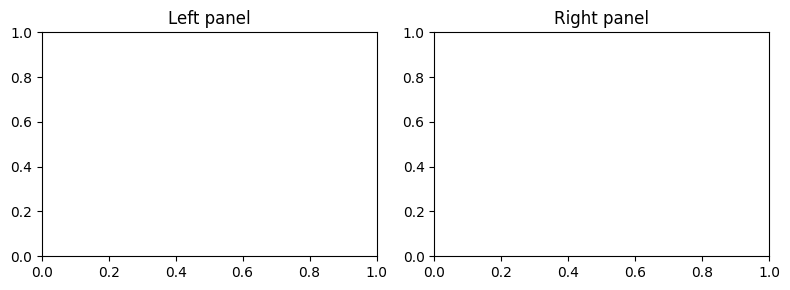

In [83]:
# ── §1 Mini-example: 1×2 figure skeleton ────────────────────────────────────
# Run this to see what plt.subplots(1, 2) gives you before adding any plots.

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
# axes is now a list of 2 Axes objects: axes[0] (left) and axes[1] (right)

axes[0].set_title('Left panel')    # just a title, no data yet
axes[1].set_title('Right panel')

# Both panels are empty — the exercise asks you to plot something in each one.
plt.tight_layout()
plt.show()

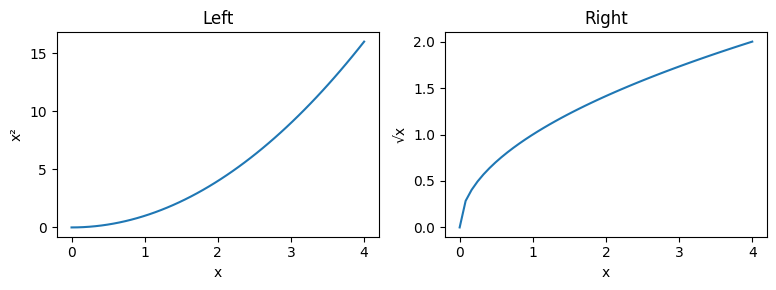

In [84]:
# ── §1 Exercise 1 — template (replace the ... with your code) ───────────────

# np.linspace(start, stop, num) creates 'num' evenly spaced values from start to stop.
# Here: 50 values from 0 to 4.
x = np.linspace(0, 4, 50)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].plot(x, x**2)         # ← plot x squared
axes[0].set_title('Left')
axes[0].set_xlabel('x')
axes[0].set_ylabel('x²')

axes[1].plot(x, np.sqrt(x))         # ← plot square root of x
axes[1].set_title('Right')
axes[1].set_xlabel('x')
axes[1].set_ylabel('√x')

plt.tight_layout()
plt.show()

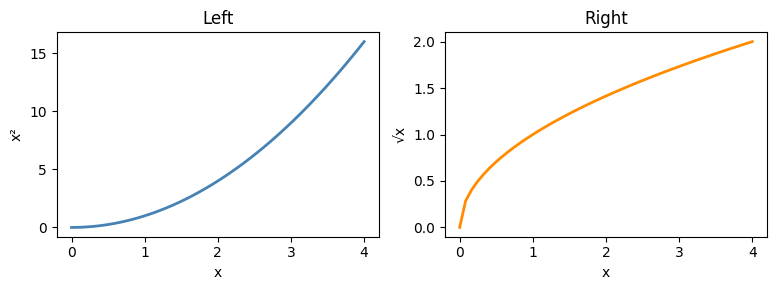

In [85]:
# ── §1 SOLUTION ─────────────────────────────────────────────────────────────
x = np.linspace(0, 4, 50)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].plot(x, x**2, color='steelblue', lw=2)
axes[0].set_title('Left')
axes[0].set_xlabel('x')
axes[0].set_ylabel('x²')

axes[1].plot(x, np.sqrt(x), color='darkorange', lw=2)
axes[1].set_title('Right')
axes[1].set_xlabel('x')
axes[1].set_ylabel('√x')

plt.tight_layout()
plt.show()

---
## §2 Scatter Plot — 2D Cluster Embeddings

After training, you will run PCA on your MLP embeddings and plot the 2D result.
Points are coloured by cluster label. `ax.scatter` is the tool for this.

**Key arguments:**

| Argument | What it does |
|----------|--------------|
| `color=` | Colour of the markers — one colour per `ax.scatter()` call |
| `s=25` | Marker size in points² — 25 is a good default |
| `alpha=0.75` | Opacity (0 = invisible, 1 = solid) — 0.75 lets overlapping points show through |
| `label=` | Text shown in the legend — required for `ax.legend()` to work |

**The `mask` pattern** — how to plot one cluster at a time:

```python
mask = cluster_labels == k   # boolean array: True where label equals k, False elsewhere
X[mask, 0]                   # x-coordinates of cluster k's points only
X[mask, 1]                   # y-coordinates of cluster k's points only
```

The worked example loops over `k = 0, 1, 2` and applies this pattern three times,
once per cluster.

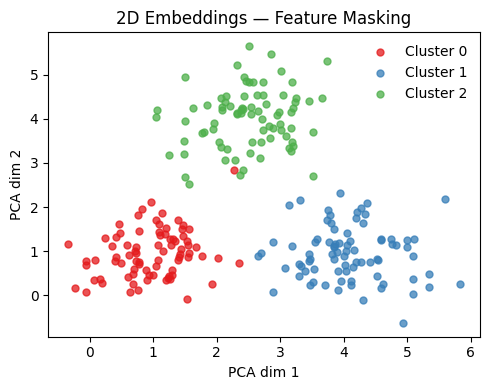

In [86]:
# ── §2 Worked example ───────────────────────────────────────────────────────

# Three hex colour codes — one per cluster.
# '#e41a1c' = red, '#377eb8' = blue, '#4daf4a' = green
COLORS = ['#e41a1c', '#377eb8', '#4daf4a']

fig, ax = plt.subplots(figsize=(5, 4))

# Loop over each cluster index k = 0, 1, 2
for k in range(3):
    # mask is a boolean array of length 240.
    # mask[i] is True if point i belongs to cluster k, False otherwise.
    mask = cluster_labels == k

    # X[mask, 0]: select all rows where mask is True, take column 0 (x-coordinate)
    # X[mask, 1]: select all rows where mask is True, take column 1 (y-coordinate)
    ax.scatter(
        X[mask, 0],          # x positions of cluster k's points, X[mask][:, 0] erst Zeilen filtern, dann Spalte 0 nehmen

        X[mask, 1],          # y positions of cluster k's points
        color=COLORS[k],     # colour for this cluster
        s=25,                # marker size
        alpha=0.75,          # slight transparency so overlapping points are visible
        label=f'Cluster {k}' # f'Cluster {k}' becomes 'Cluster 0', 'Cluster 1', etc.
    )

ax.set_title('2D Embeddings — Feature Masking')
ax.set_xlabel('PCA dim 1')   # the two PCA directions (no physical meaning)
ax.set_ylabel('PCA dim 2')
ax.legend(frameon=False)     # frameon=False removes the box around the legend
plt.tight_layout()
plt.show()

### Exercise 2

Add a **4th cluster** centred at `(1, 4)` with the same spread. Give it colour `'#984ea3'` (purple).
Plot all 4 clusters.

The mini-example below shows the mask pattern step-by-step for 2 clusters without a loop.
Run it first, then use the loop approach in the template.

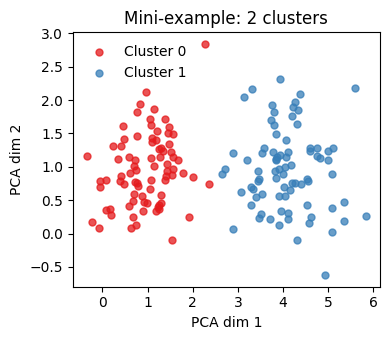

In [87]:
# ── §2 Mini-example: the mask pattern, explicit (no loop) ───────────────────

fig, ax = plt.subplots(figsize=(4, 3.5))

# Cluster 0 — manually
mask0 = cluster_labels == 0    # True for the first 80 points, False for the rest
ax.scatter(X[mask0, 0], X[mask0, 1], color='#e41a1c', s=25, alpha=0.75, label='Cluster 0')

# Cluster 1 — same pattern, different index and colour
mask1 = cluster_labels == 1
ax.scatter(X[mask1, 0], X[mask1, 1], color='#377eb8', s=25, alpha=0.75, label='Cluster 1')

# The worked example above replaces these two blocks with a for-loop over k=0,1,2.
# For your exercise: extend the data to 4 clusters and add a k=3 case.
ax.set_title('Mini-example: 2 clusters')
ax.set_xlabel('PCA dim 1'); ax.set_ylabel('PCA dim 2')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

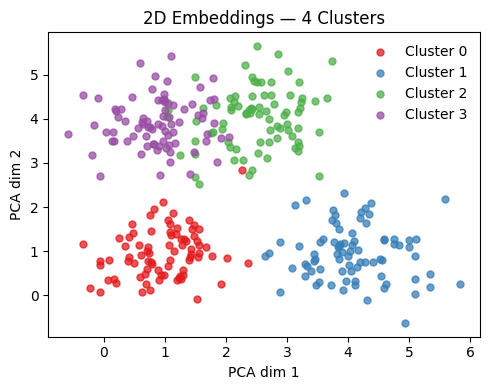

In [88]:
# ── §2 Exercise 2 — template ────────────────────────────────────────────────

# A second generator (different seed) so the 4th cluster uses fresh randomness
rng2 = np.random.default_rng(7)

# Generate 80 points around (1, 4) with the same spread as before
X_cluster3 = rng2.multivariate_normal((1, 4), 0.4 * np.eye(2), n)

# Stack X_cluster3 below the existing X (add 80 more rows)
X4 = np.vstack([X, X_cluster3])            # shape: (320, 2)
labels4 = np.append(cluster_labels, np.full(n, 3))  # 80 new labels all equal to 3

COLORS4 = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']   # ← add the purple colour for cluster 3

fig, ax = plt.subplots(figsize=(5, 4))
for k in range(4):
    mask = labels4 == k
    ax.scatter(
        X4[mask, 0],
        X4[mask, 1],
        c=COLORS4[k],
        s=25,
        alpha=0.75,
        label=f'Cluster {k}'
        )   # ← same as worked example, but use X4, labels4, COLORS4

ax.set_title('2D Embeddings — 4 Clusters')
ax.set_xlabel('PCA dim 1'); ax.set_ylabel('PCA dim 2')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

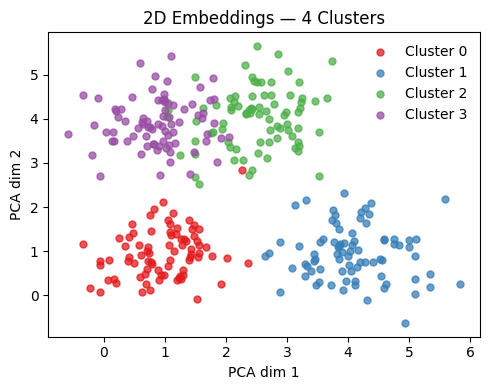

In [89]:
# ── §2 SOLUTION ─────────────────────────────────────────────────────────────
rng2 = np.random.default_rng(7)
X_cluster3 = rng2.multivariate_normal((1, 4), 0.4 * np.eye(2), n)
X4 = np.vstack([X, X_cluster3])
labels4 = np.append(cluster_labels, np.full(n, 3))

COLORS4 = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

fig, ax = plt.subplots(figsize=(5, 4))
for k in range(4):
    mask = labels4 == k
    ax.scatter(X4[mask, 0], X4[mask, 1],
               color=COLORS4[k], s=25, alpha=0.75, label=f'Cluster {k}')

ax.set_title('2D Embeddings — 4 Clusters')
ax.set_xlabel('PCA dim 1'); ax.set_ylabel('PCA dim 2')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

---
## §3 Line Plot — Training Loss Curve

Every experiment run produces a loss curve. Plotting train and validation loss together
tells you whether training converged and whether the model is overfitting.

**What is NT-Xent loss?** It is the "contrastive loss" used in your thesis.
It starts high (the network is random) and should fall toward a low value as training
progresses. If it does not fall, training is not working.

**Key arguments:**

| Argument | What it does |
|----------|--------------|
| `lw=2` | Line width — 2 is slightly thicker than the default (1.5) |
| `ls='--'` | Line style — `'-'` solid (default), `'--'` dashed, `':'` dotted |
| `label=` | Text for the legend — required for `ax.legend()` |
| `ax.axvline(x=v)` | Draws a vertical line at x-position `v` across the full plot |
| `color='grey'` | Any named colour or hex code |

**Two lines, one Axes:** calling `ax.plot()` twice on the same `ax` object
draws both lines in the same panel. Matplotlib automatically assigns different colours
if you do not specify `color=`.

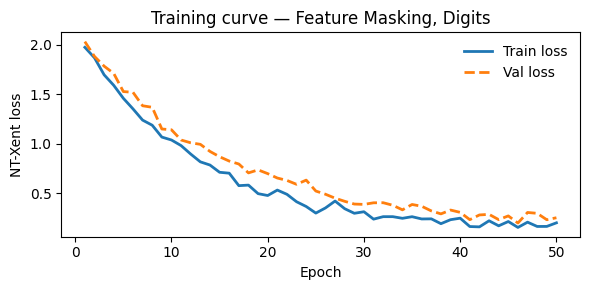

In [90]:
# ── §3 Worked example ───────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 3))

# First call to ax.plot: draws the training loss as a solid line
ax.plot(epochs, loss_tr, lw=2, label='Train loss')

# Second call to ax.plot on the *same ax*: draws validation loss as a dashed line
# ls='--' makes it dashed so you can distinguish it from the solid train line
ax.plot(epochs, loss_val, lw=2, ls='--', label='Val loss')

ax.set_xlabel('Epoch')
ax.set_ylabel('NT-Xent loss')
ax.set_title('Training curve — Feature Masking, Digits')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Exercise 3

Find the epoch where the **validation loss is at its minimum** and add a vertical
dotted line there. Also print the best epoch number to the console.

The mini-example shows how `ax.axvline` works with a fixed value.
Your task is to replace that fixed value with the actual best epoch.

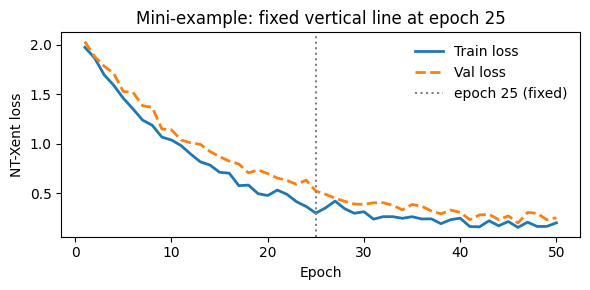

In [91]:
# ── §3 Mini-example: axvline with a fixed value ─────────────────────────────

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(epochs, loss_tr,  lw=2, label='Train loss')
ax.plot(epochs, loss_val, lw=2, ls='--', label='Val loss')

# ax.axvline(x=value): draws a vertical line at x=value spanning the full height.
# ls=':' makes it dotted; color='grey' keeps it from competing with the data lines.
ax.axvline(25, color='grey', ls=':', lw=1.5, label='epoch 25 (fixed)')

ax.set_xlabel('Epoch'); ax.set_ylabel('NT-Xent loss')
ax.set_title('Mini-example: fixed vertical line at epoch 25')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
# Your task: find the ACTUAL best epoch and use that instead of 25.

Best epoch: 46


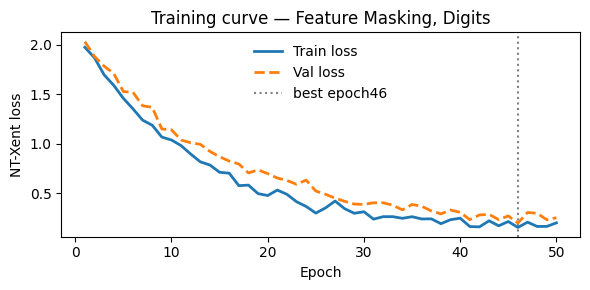

In [92]:
# ── §3 Exercise 3 — template ────────────────────────────────────────────────

# np.argmin(array) returns the *index* of the smallest value in the array.
# Hint: epochs start at 1, but array indices start at 0.
#       So if the minimum is at index 12, the epoch number is 12 + 1 = 13.
best_epoch = np.argmin(loss_val) + 1   # ← your code here
print(f'Best epoch: {best_epoch}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(epochs, loss_tr,  lw=2, label='Train loss')
ax.plot(epochs, loss_val, lw=2, ls='--', label='Val loss')
ax.axvline(best_epoch, color='grey', ls=':', label= f'best epoch{best_epoch}')    # ← use best_epoch, grey dotted line, add a label
ax.set_xlabel('Epoch'); ax.set_ylabel('NT-Xent loss')
ax.set_title('Training curve — Feature Masking, Digits')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

Best epoch: 46


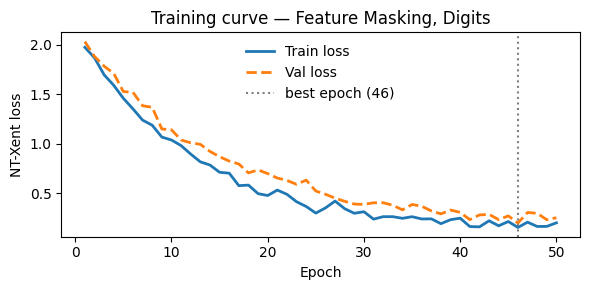

In [93]:
# ── §3 SOLUTION ─────────────────────────────────────────────────────────────

# np.argmin returns the 0-based index of the minimum value.
# +1 converts it to a 1-based epoch number.
best_epoch = int(np.argmin(loss_val)) + 1
print(f'Best epoch: {best_epoch}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(epochs, loss_tr,  lw=2, label='Train loss')
ax.plot(epochs, loss_val, lw=2, ls='--', label='Val loss')
ax.axvline(best_epoch, color='grey', ls=':', lw=1.5,
           label=f'best epoch ({best_epoch})')
ax.set_xlabel('Epoch'); ax.set_ylabel('NT-Xent loss')
ax.set_title('Training curve — Feature Masking, Digits')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

---
## §4 Histogram — Feature Distributions

Before training, you inspect your tabular datasets. A histogram shows how the values
in a column are spread out — this helps you spot skew, outliers, and whether scaling is needed.

**Two distributions you will encounter:**

- **Normal (bell curve):** most values cluster around the middle (the mean);
  fewer values appear far from it. Height, age, and many measurement errors follow this shape.
  `feat_age` is normal — most simulated ages are near 35, rarely very young or very old.

- **Exponential (right-skewed):** most values are small, but the distribution has a long
  tail of large values. Income, response times, and file sizes often follow this.
  `feat_income` is exponential — most incomes are low, a few are very high.

**Key arguments:**

| Argument | What it does |
|----------|--------------|
| `bins=30` | Number of equal-width bars to split the data range into |
| `alpha=0.6` | Transparency — set below 1 so overlapping bars are both visible |
| `density=True` | Rescales bars so total area = 1, making distributions of different sizes comparable |
| `edgecolor='white'` | Thin white border between bars — improves readability |

**What does `density=True` mean visually?**
Without it, bar height = count of data points in that range — two datasets of different
sizes are hard to compare because one will simply be taller everywhere.
With `density=True`, the bars are rescaled so the total area under all bars equals 1.
Both distributions are now on the same scale, and you can compare their *shapes* fairly.

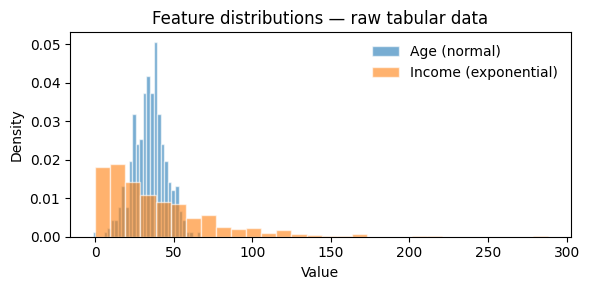

In [94]:
# ── §4 Worked example ───────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 3))

# First ax.hist call: plots feat_age as a set of bars
ax.hist(feat_age,
        bins=30,           # 30 equal-width bars across the range of feat_age
        alpha=0.6,         # 60% opaque — lets the second histogram show through
        density=True,      # normalise so total area = 1
        edgecolor='white', # white border between bars
        label='Age (normal)')

# Second ax.hist call on the *same ax*: adds a second set of bars on top
ax.hist(feat_income,
        bins=30,
        alpha=0.6,
        density=True,
        edgecolor='white',
        label='Income (exponential)')

ax.set_xlabel('Value')
ax.set_ylabel('Density')     # y-axis label for density (not count)
ax.set_title('Feature distributions — raw tabular data')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Exercise 4

Add a **third feature** to the histogram: a binary column (values are only 0 or 1).
Generate it with: `feat_binary = rng.binomial(1, 0.3, 400).astype(float)`

- `rng.binomial(1, 0.3, 400)` flips a coin 400 times where heads (`1`) comes up 30% of the time.
  `.astype(float)` converts the integer array to floats so matplotlib accepts it.
- Use **2 bins** (not 30) because there are only two possible values (0 and 1).
- Update the title to `'Feature distributions (binary uses 2 bins)'`.

The pattern is the same as the worked example — just add one more `ax.hist()` call.

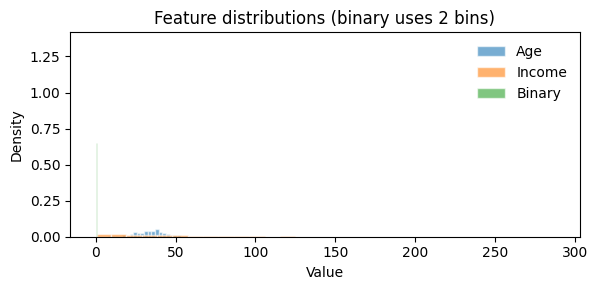

In [95]:
# ── §4 Exercise 4 — template ────────────────────────────────────────────────
feat_binary = rng.binomial(1, 0.3, 400).astype(float)

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(feat_age,    bins=30, alpha=0.6, density=True, edgecolor='white', label='Age')
ax.hist(feat_income, bins=30, alpha=0.6, density=True, edgecolor='white', label='Income')
ax.hist(feat_binary, bins=2, alpha=0.6, density=True, edgecolor='white', label='Binary' )   # ← bins=2, alpha, density, edgecolor, label='Binary'
ax.set_xlabel('Value'); ax.set_ylabel('Density')
ax.set_title('Feature distributions (binary uses 2 bins)')           # ← update the title
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

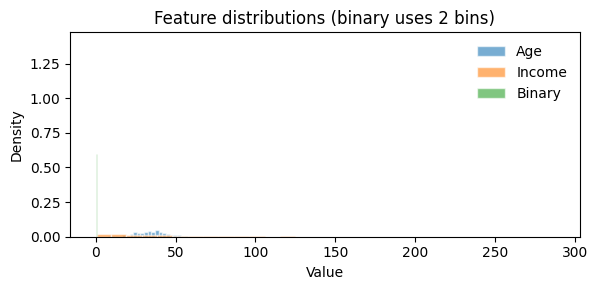

In [96]:
# ── §4 SOLUTION ─────────────────────────────────────────────────────────────
feat_binary = rng.binomial(1, 0.3, 400).astype(float)

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(feat_age,    bins=30, alpha=0.6, density=True, edgecolor='white', label='Age')
ax.hist(feat_income, bins=30, alpha=0.6, density=True, edgecolor='white', label='Income')
ax.hist(feat_binary, bins=2,  alpha=0.6, density=True, edgecolor='white', label='Binary')
ax.set_xlabel('Value'); ax.set_ylabel('Density')
ax.set_title('Feature distributions (binary uses 2 bins)')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

---
## §5 Bar Chart — NMI / ARI Comparison

The main quantitative result of your thesis is a table/figure comparing augmentation
techniques on NMI and ARI. A horizontal bar chart (`barh`) is the clearest way to
show named categories.

**Key arguments:**

| Argument | What it does |
|----------|--------------|
| `ax.barh(y_positions, values)` | Draws horizontal bars at the given y-positions |
| `ax.bar_label(bars, fmt='%.2f')` | Adds the numeric value at the end of each bar |
| `padding=3` | Gap (in points) between the bar tip and the label text |
| `ax.set_xlim(0, 0.75)` | Sets the x-axis range — gives space for the value labels |

**Grouped bars** require a small trick: instead of using method names directly as
y-positions, we use integers `[0, 1, 2, 3, 4]` and shift each group by `±width/2`:

```
y = [0,   1,   2,   3,   4  ]   ← integer positions for 5 methods

NMI bars: y + width/2  → [0.175, 1.175, 2.175, 3.175, 4.175]  (above centre)
ARI bars: y - width/2  → [-0.175, 0.825, 1.825, 2.825, 3.825] (below centre)
```

We then relabel the y-axis with the actual method names using `ax.set_yticks` and `ax.set_yticklabels`.

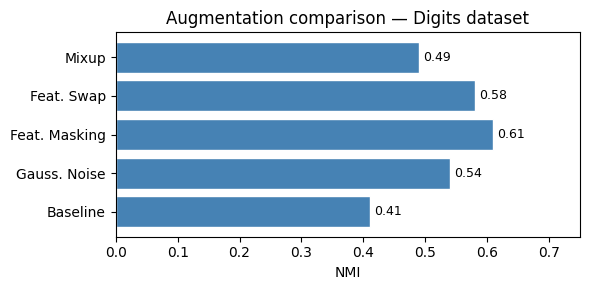

In [97]:
# ── §5 Worked example — single metric ──────────────────────────────────────

# Extract keys and values from the nmi dict into separate lists
methods = list(nmi.keys())    # ['Baseline', 'Gauss. Noise', 'Feat. Masking', ...]
values  = list(nmi.values())  # [0.41, 0.54, 0.61, ...]

fig, ax = plt.subplots(figsize=(6, 3))

# ax.barh(y_labels, x_values): horizontal bars
# Here we pass method names directly as y_labels — matplotlib places one bar per name.
bars = ax.barh(methods, values, color='steelblue', edgecolor='white')

# ax.bar_label adds the numeric value at the tip of each bar.
# fmt='%.2f' formats the number to 2 decimal places (e.g. 0.61)
# padding=3 leaves a 3-point gap between bar tip and text
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)

ax.set_xlabel('NMI')
ax.set_title('Augmentation comparison — Digits dataset')
ax.set_xlim(0, 0.75)   # extend the x-axis to give room for the value labels
plt.tight_layout()
plt.show()

### Exercise 5

Extend the chart to show **both NMI and ARI** as grouped horizontal bars.

The mini-example below shows the offset technique with a simple 3-category example.
Run it first, then apply the same pattern to the 5-method NMI/ARI data.

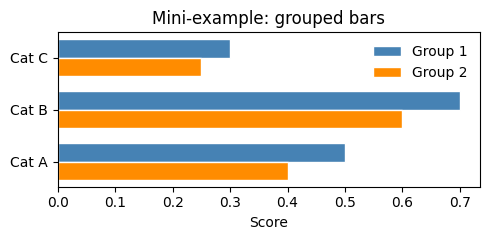

In [98]:
# ── §5 Mini-example: grouped bars with 3 categories ─────────────────────────

cats   = ['Cat A', 'Cat B', 'Cat C']
group1 = [0.5, 0.7, 0.3]
group2 = [0.4, 0.6, 0.25]

# np.arange(3) → [0, 1, 2]: integer y-positions for 3 categories
y = np.arange(3)
w = 0.35   # width of each individual bar

fig, ax = plt.subplots(figsize=(5, 2.5))

# Group 1 bars: shifted UP by half a width (so they sit above each integer position)
ax.barh(y + w/2, group1, w, label='Group 1', color='steelblue', edgecolor='white')

# Group 2 bars: shifted DOWN by half a width
ax.barh(y - w/2, group2, w, label='Group 2', color='darkorange', edgecolor='white')

# Replace integer tick labels with the actual category names
ax.set_yticks(y)
ax.set_yticklabels(cats)
ax.legend(frameon=False)
ax.set_xlabel('Score')
ax.set_title('Mini-example: grouped bars')
plt.tight_layout(); plt.show()
# Your exercise: apply this exact pattern to 5 methods (NMI and ARI)

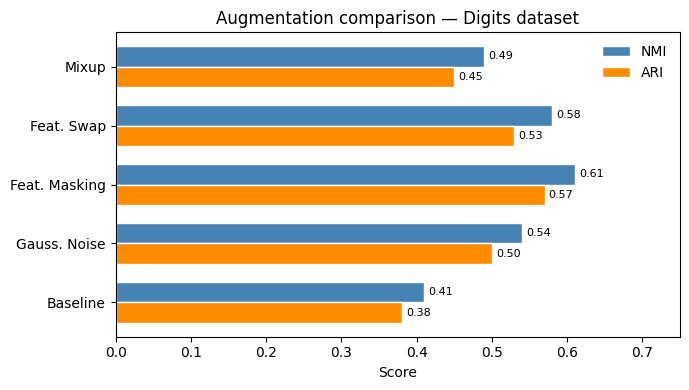

In [99]:
# ── §5 Exercise 5 — template ────────────────────────────────────────────────

methods  = list(nmi.keys())
nmi_vals = list(nmi.values())
ari_vals = list(ari.values())

y     = np.arange(len(methods))  # [0, 1, 2, 3, 4] — one position per method
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))

bars_nmi = ax.barh(y + width/2, nmi_vals, width,
                   label='NMI', color='steelblue', edgecolor='white')
bars_ari = ax.barh(y - width/2, ari_vals, width, label='ARI', color='darkorange', edgecolor='white')   # ← same pattern: y - width/2, ari_vals, width, label, colour

ax.bar_label(bars_nmi, fmt='%.2f', padding=3, fontsize=8)
ax.bar_label(bars_ari, fmt='%.2f', padding=3, fontsize=8)         # ← add labels on ARI bars too

ax.set_yticks(y)
ax.set_yticklabels(methods)
ax.set_xlabel('Score')
ax.set_title('Augmentation comparison — Digits dataset')
ax.legend(frameon=False)
ax.set_xlim(0, 0.75)
plt.tight_layout(); plt.show()

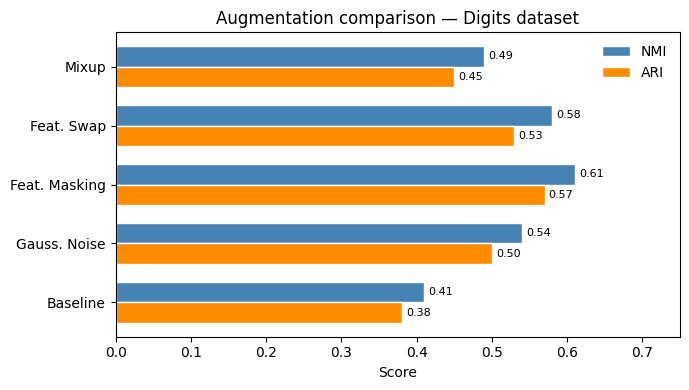

In [100]:
# ── §5 SOLUTION ─────────────────────────────────────────────────────────────
methods  = list(nmi.keys())
nmi_vals = list(nmi.values())
ari_vals = list(ari.values())

y = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars_nmi = ax.barh(y + width/2, nmi_vals, width,
                   label='NMI', color='steelblue',  edgecolor='white')
bars_ari = ax.barh(y - width/2, ari_vals, width,
                   label='ARI', color='darkorange', edgecolor='white')
ax.bar_label(bars_nmi, fmt='%.2f', padding=3, fontsize=8)
ax.bar_label(bars_ari, fmt='%.2f', padding=3, fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(methods)
ax.set_xlabel('Score')
ax.set_title('Augmentation comparison — Digits dataset')
ax.legend(frameon=False); ax.set_xlim(0, 0.75)
plt.tight_layout(); plt.show()

---
## §6 Subplots — Multi-Panel Results Figure

Thesis figures often put several plots side by side: embedding scatter + loss curve +
bar chart, all in one figure. `plt.subplots(rows, cols)` creates a grid of panels.

**How `axes` is structured:**

```python
fig, axes = plt.subplots(1, 3)   # → axes is a 1D list: [axes[0], axes[1], axes[2]]
fig, axes = plt.subplots(2, 2)   # → axes is a 2D array:
                                 #     axes[0, 0]  axes[0, 1]
                                 #     axes[1, 0]  axes[1, 1]
```

**Key extras:**

| Call | What it does |
|------|--------------|
| `fig.suptitle('...', fontweight='bold')` | Shared title above all panels |
| `plt.tight_layout()` | Prevents panel labels from overlapping each other |
| `plt.subplots_adjust(wspace=0.45)` | Fine-tunes horizontal space between panels |

**Pattern:** call `tight_layout()` first, then `subplots_adjust()` to fine-tune.

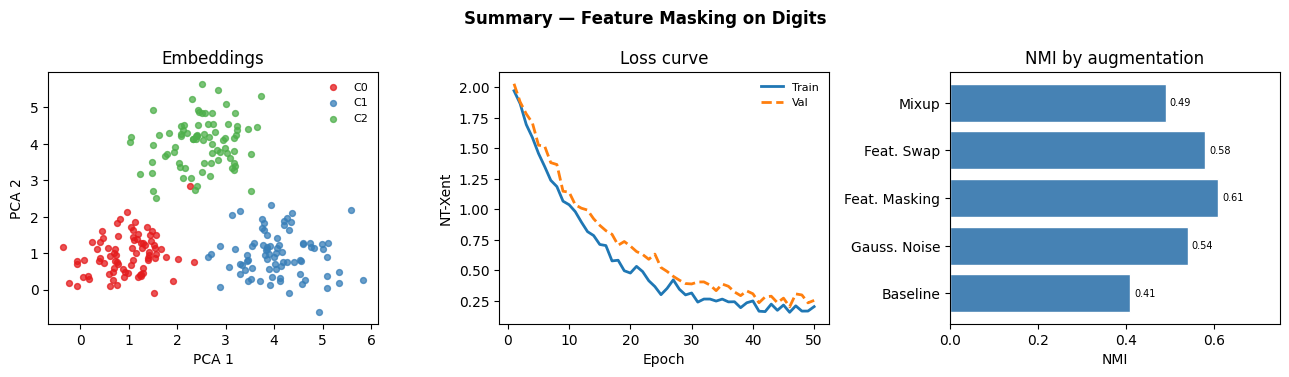

In [101]:
# ── §6 Worked example — 3-panel summary figure ──────────────────────────────

COLORS = ['#e41a1c', '#377eb8', '#4daf4a']

# Create 3 side-by-side panels. axes is a list of 3 Axes objects.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

# Shared title above all 3 panels
fig.suptitle('Summary — Feature Masking on Digits', fontsize=12, fontweight='bold')

# ── Panel 0: Scatter (embeddings) ──
ax = axes[0]          # give the first panel a short alias 'ax' for convenience
for k in range(3):
    mask = cluster_labels == k
    ax.scatter(X[mask, 0], X[mask, 1],
               color=COLORS[k], s=18, alpha=0.75, label=f'C{k}')
ax.set_title('Embeddings')
ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
ax.legend(frameon=False, fontsize=8)

# ── Panel 1: Line (loss curve) ──
ax = axes[1]
ax.plot(epochs, loss_tr,  lw=2,          label='Train')
ax.plot(epochs, loss_val, lw=2, ls='--', label='Val')
ax.set_title('Loss curve')
ax.set_xlabel('Epoch'); ax.set_ylabel('NT-Xent')
ax.legend(frameon=False, fontsize=8)

# ── Panel 2: Bar (NMI scores) ──
ax = axes[2]
bars = ax.barh(list(nmi.keys()), list(nmi.values()),
               color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=7)
ax.set_title('NMI by augmentation')
ax.set_xlabel('NMI'); ax.set_xlim(0, 0.75)

plt.tight_layout()
plt.show()

### Exercise 6

Modify the figure above in two ways:
1. Add `plt.subplots_adjust(wspace=0.45)` after `tight_layout()` to add breathing room.
2. On the scatter panel, mark the **centroid of Cluster 0** with an arrow annotation.

The mini-example shows how `ax.annotate` works. Run it first.

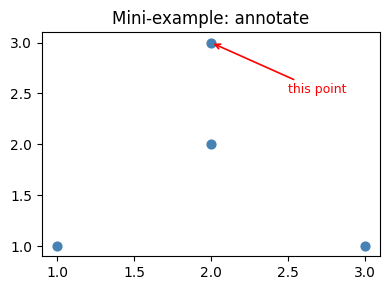

In [102]:
# ── §6 Mini-example: ax.annotate ────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter([1, 2, 3, 2], [1, 2, 1, 3], s=40, color='steelblue')

# ax.annotate(text, xy=arrow_tip, xytext=text_position, arrowprops=...)
#   text          — the label string
#   xy            — the (x, y) point the arrow points TO
#   xytext        — the (x, y) position of the text label
#   arrowprops    — dict controlling the arrow appearance
#     arrowstyle='->' draws a simple arrow
ax.annotate('this point',
            xy=(2, 3),                               # arrow tip: the data point
            xytext=(2.5, 2.5),                       # text label offset from the point
            fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

ax.set_title('Mini-example: annotate')
plt.tight_layout(); plt.show()
# Your task: use this pattern on the scatter panel of the summary figure,
# pointing to the centroid of Cluster 0.

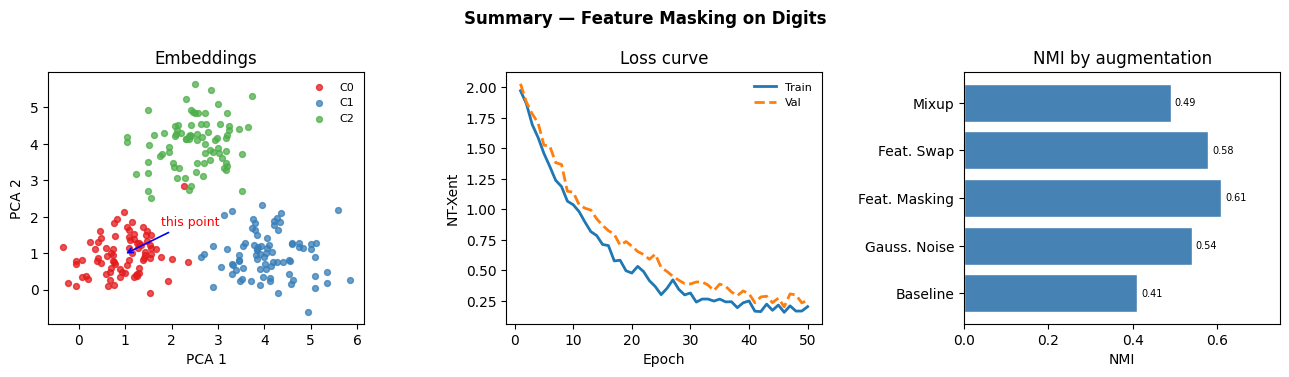

In [103]:
# ── §6 Exercise 6 — template ────────────────────────────────────────────────

COLORS = ['#e41a1c', '#377eb8', '#4daf4a']

# .mean(axis=0): average across rows (axis 0), keeping the 2 columns.
# Result: the (x, y) centre of cluster 0's 80 points.
c0_centroid = X[cluster_labels == 0].mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
fig.suptitle('Summary — Feature Masking on Digits', fontsize=12, fontweight='bold')

ax = axes[0]
for k in range(3):
    mask = cluster_labels == k
    ax.scatter(X[mask, 0], X[mask, 1],
               color=COLORS[k], s=18, alpha=0.75, label=f'C{k}')
ax.set_title('Embeddings')
ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
ax.legend(frameon=False, fontsize=8)
ax.annotate('this point', xy=c0_centroid, xytext= c0_centroid + 0.8, fontsize=9, color='red', arrowprops=dict(arrowstyle='->', color='blue', lw=1.2))   # ← point to c0_centroid; offset xytext by ~(+0.8, +0.8)

ax = axes[1]
ax.plot(epochs, loss_tr,  lw=2,          label='Train')
ax.plot(epochs, loss_val, lw=2, ls='--', label='Val')
ax.set_title('Loss curve'); ax.set_xlabel('Epoch'); ax.set_ylabel('NT-Xent')
ax.legend(frameon=False, fontsize=8)

ax = axes[2]
bars = ax.barh(list(nmi.keys()), list(nmi.values()), color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=7)
ax.set_title('NMI by augmentation'); ax.set_xlabel('NMI'); ax.set_xlim(0, 0.75)

plt.tight_layout()
plt.subplots_adjust(wspace=0.45)   # ← wspace=0.45
plt.show()

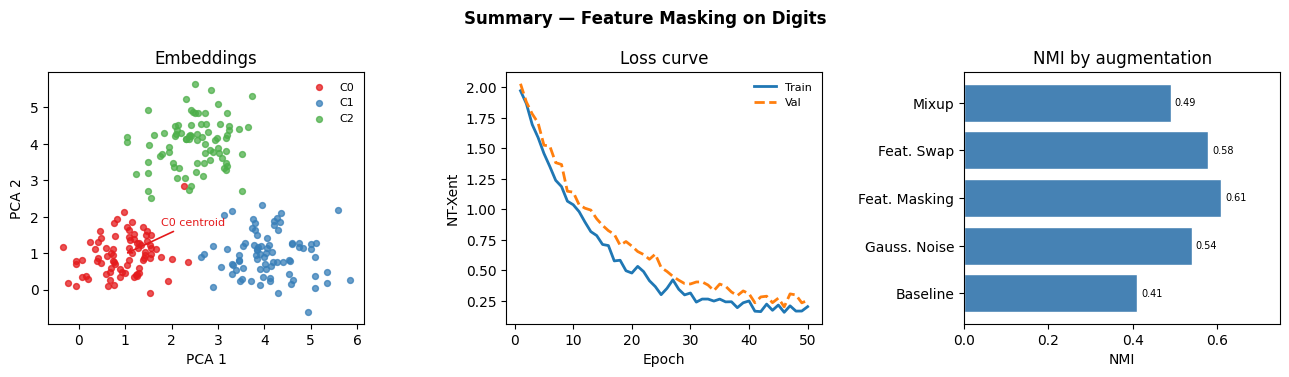

In [104]:
# ── §6 SOLUTION ─────────────────────────────────────────────────────────────
COLORS = ['#e41a1c', '#377eb8', '#4daf4a']
c0_centroid = X[cluster_labels == 0].mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
fig.suptitle('Summary — Feature Masking on Digits', fontsize=12, fontweight='bold')

ax = axes[0]
for k in range(3):
    mask = cluster_labels == k
    ax.scatter(X[mask, 0], X[mask, 1],
               color=COLORS[k], s=18, alpha=0.75, label=f'C{k}')
ax.set_title('Embeddings')
ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
ax.legend(frameon=False, fontsize=8)
ax.annotate('C0 centroid',
            xy=c0_centroid,
            xytext=(c0_centroid[0] + 0.8, c0_centroid[1] + 0.8),
            fontsize=8, color='#e41a1c',
            arrowprops=dict(arrowstyle='->', color='#e41a1c', lw=1.2))

ax = axes[1]
ax.plot(epochs, loss_tr,  lw=2,          label='Train')
ax.plot(epochs, loss_val, lw=2, ls='--', label='Val')
ax.set_title('Loss curve'); ax.set_xlabel('Epoch'); ax.set_ylabel('NT-Xent')
ax.legend(frameon=False, fontsize=8)

ax = axes[2]
bars = ax.barh(list(nmi.keys()), list(nmi.values()), color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=7)
ax.set_title('NMI by augmentation'); ax.set_xlabel('NMI'); ax.set_xlim(0, 0.75)

plt.tight_layout()
plt.subplots_adjust(wspace=0.45)
plt.show()

---
## §7 Publication-Ready Export — `savefig`

Thesis figures go into your LaTeX document via `\includegraphics{fig/results.pdf}`.

**Vector (PDF) vs. raster (PNG):**

- **PDF** stores mathematical descriptions of lines and curves. Scale it to any size on any
  screen or printer — it stays perfectly sharp. Always use PDF for LaTeX.
- **PNG** stores a fixed grid of pixels. Enlarge it and it blurs. Fine for presentations
  and web pages where you control the display size.

**Essential arguments:**

| Argument | What it does |
|----------|--------------|
| `'filename.pdf'` | Output path — relative to the notebook's folder |
| `bbox_inches='tight'` | Trims empty whitespace around the figure edges |
| `dpi=150` | Pixels-per-inch — only affects PNG/raster formats, ignored for PDF |

> **Important:** call `plt.savefig()` **before** `plt.show()`. Once `show()` runs,
> the figure is cleared and saving it produces a blank file.

Saved: results_digits.pdf  and  results_digits.png


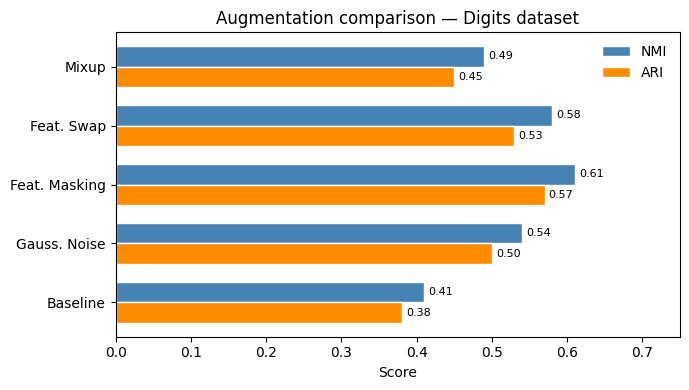

In [105]:
# ── §7 Worked example — save to PDF and PNG ─────────────────────────────────

methods  = list(nmi.keys())
nmi_vals = list(nmi.values())
ari_vals = list(ari.values())
y = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars_nmi = ax.barh(y + width/2, nmi_vals, width,
                   label='NMI', color='steelblue',  edgecolor='white')
bars_ari = ax.barh(y - width/2, ari_vals, width,
                   label='ARI', color='darkorange', edgecolor='white')
ax.bar_label(bars_nmi, fmt='%.2f', padding=3, fontsize=8)
ax.bar_label(bars_ari, fmt='%.2f', padding=3, fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(methods)
ax.set_xlabel('Score')
ax.set_title('Augmentation comparison — Digits dataset')
ax.legend(frameon=False); ax.set_xlim(0, 0.75)
plt.tight_layout()

# ── Save BEFORE show() ──────────────────────────────────────────────────────
plt.savefig('results_digits.pdf', bbox_inches='tight')          # for LaTeX
plt.savefig('results_digits.png', dpi=150, bbox_inches='tight') # for slides/README
print('Saved: results_digits.pdf  and  results_digits.png')

plt.show()   # renders in notebook — call this last

---
## ★ Capstone Exercise

You receive a results dictionary from one of your benchmark runs.
Produce a **publication-ready figure** and save it as `capstone_results.pdf`.

**Requirements:**
1. Horizontal bar chart of NMI scores, **sorted ascending** (best bar appears at the top)
2. Numeric value label on each bar (`fmt='%.2f'`)
3. The best-performing bar is highlighted in red (`'#e41a1c'`); all others use `'steelblue'`
4. Bold title, labelled x-axis
5. Saved as `capstone_results.pdf` with `bbox_inches='tight'`

**Hints:**
- `sorted(results.items(), key=lambda x: x[1])` returns a list of `(name, value)` pairs
  sorted by value ascending. After this sort, the best result is the **last** element.
- `zip(*sorted_items)` unpacks the list of pairs into two separate tuples: names and values.

Saved: capstone_results.pdf


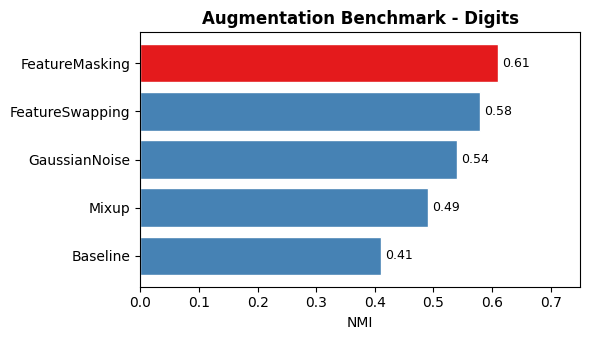

In [106]:
# ── Capstone — YOUR CODE ────────────────────────────────────────────────────
results = {
    'FeatureMasking':  0.61,
    'GaussianNoise':   0.54,
    'FeatureSwapping': 0.58,
    'Mixup':           0.49,
    'Baseline':        0.41,
}

# Step 1: sort items ascending by value
#         sorted_items = sorted(...)
#         methods, values = zip(*sorted_items)

# Step 2: build a colour list
#         Start with ['steelblue'] * len(methods)
#         Set colors[-1] = '#e41a1c'  (last = best after ascending sort)

# Step 3: plot with ax.barh, add bar_label, set title (fontweight='bold'), save PDF

# YOUR CODE BELOW
sorted_items = sorted(results.items(), key=lambda x: x[1])
methods, values = zip(*sorted_items)

colors = ['steelblue'] * len(methods)
colors[-1] = '#e41a1c'

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.barh(methods, values, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_xlabel('NMI')
ax.set_title('Augmentation Benchmark - Digits', fontweight='bold')
ax.set_xlim(0, 0.75)
plt.tight_layout()

plt.savefig('capstone_results.pdf', bbox_inches='tight')
print('Saved: capstone_results.pdf')

plt.show()


Saved: capstone_results.pdf


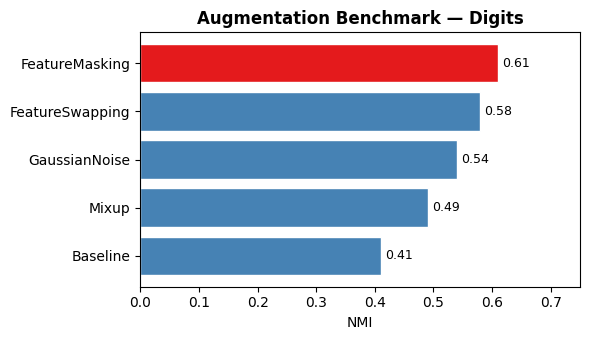

In [107]:
# ── Capstone — SOLUTION ─────────────────────────────────────────────────────
results = {
    'FeatureMasking':  0.61,
    'GaussianNoise':   0.54,
    'FeatureSwapping': 0.58,
    'Mixup':           0.49,
    'Baseline':        0.41,
}

# Sort by value ascending — best result ends up last
sorted_items = sorted(results.items(), key=lambda x: x[1])

# zip(*sorted_items) is the inverse of zip: it unpacks [(a,1),(b,2)] into (a,b) and (1,2)
methods, values = zip(*sorted_items)

# All bars steelblue; highlight the last (= best) in red
colors = ['steelblue'] * len(methods)
colors[-1] = '#e41a1c'

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.barh(methods, values, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_xlabel('NMI')
ax.set_title('Augmentation Benchmark — Digits', fontweight='bold')
ax.set_xlim(0, 0.75)
plt.tight_layout()

plt.savefig('capstone_results.pdf', bbox_inches='tight')
print('Saved: capstone_results.pdf')
plt.show()